In [1]:
import numpy as np
from PIL import Image
import taichi as ti
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
from utils import run_optimization, resample_polyline, get_area

ti.init(arch=ti.gpu)

[Taichi] version 1.7.3, llvm 15.0.1, commit 5ec301be, win, python 3.12.3
[Taichi] Starting on arch=cuda


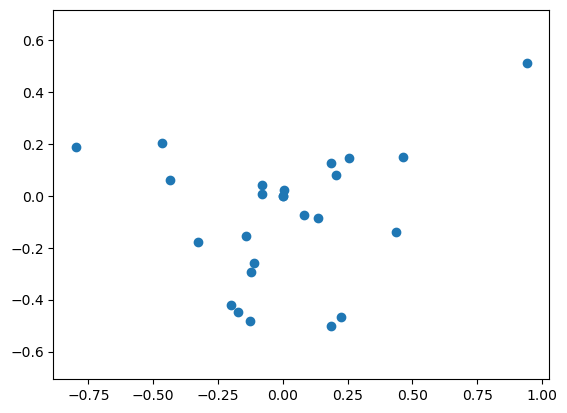

In [145]:
def init_trajectory(control_point_num):  # 生成初始轨迹
    xs, ys, rotations = resample_polyline([
        [0, 0, 0],
        [0, 0, 2 * np.pi]
    ], control_point_num).T
    return xs, ys, rotations

xs, ys, rotations = init_trajectory(  # 初始轨迹
    control_point_num=25,  # 轨迹的控制点数量
)

xs[1:-1] += np.random.randn(len(xs) - 2) * 0.3
ys[1:-1] += np.random.randn(len(ys) - 2) * 0.3

plt.scatter(xs, ys)
plt.axis('equal')
pass

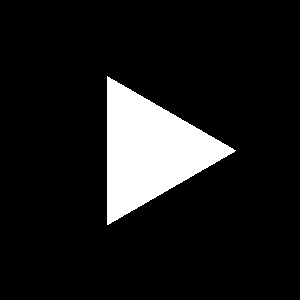

In [72]:
# 可视化墙（白色区域为墙）

from utils import test_forbidden_function

normal_0 = ti.Vector([np.cos(np.pi / 3), np.sin(np.pi / 3)])
normal_1 = ti.Vector([-1., 0.])
normal_2 = ti.Vector([np.cos(-np.pi / 3), np.sin(-np.pi / 3)])
edge_distance = 3 ** 0.5 / 6
@ti.func
def is_forbidden(x1, y1, x2, y2):  # 指定哪里是墙
    v = ti.Vector([x2, y2])
    return ti.math.dot(v, normal_0) < edge_distance and ti.math.dot(v, normal_1) < edge_distance and ti.math.dot(v, normal_2) < edge_distance  # 等边三角形内是墙

image = test_forbidden_function(
    is_forbidden,
    -1, 1, -1, 1, [300, 300],
    # wall_normal=[0, 0.05]
)
Image.fromarray(np.array(image.T[::-1] * 255, dtype=np.uint8))

In [ ]:
xs, ys, rotations = np.load('../trajectory/能让等边三角形旋转一周的房间_4/sofa_600.npy')

In [ ]:
# delta_x = xs[0] - (xs[1] + xs[-2]) / 2
# delta_y = ys[0] - (ys[1] + ys[-2]) / 2
# xs[1:-1] += delta_x
# ys[1:-1] += delta_y

(-0.4257399545840448,
 0.34377697693983506,
 -0.41986217199648734,
 0.3971124491057202)

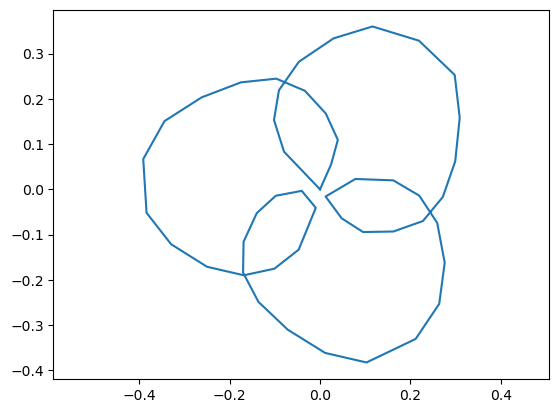

In [162]:
plt.plot(xs, ys)
plt.axis('equal')

Initial survivors: 3.127330780029297
iter 500 / 10000, maximal_area=3.1285552978515625
iter 1000 / 10000, maximal_area=3.1289710998535156
iter 1500 / 10000, maximal_area=3.129222869873047
iter 2000 / 10000, maximal_area=3.1294326782226562
iter 2500 / 10000, maximal_area=3.129547119140625
iter 3000 / 10000, maximal_area=3.129619598388672
iter 3500 / 10000, maximal_area=3.1297454833984375
iter 4000 / 10000, maximal_area=3.1298446655273438
iter 4500 / 10000, maximal_area=3.1299095153808594
iter 5000 / 10000, maximal_area=3.1300315856933594
iter 5500 / 10000, maximal_area=3.1301193237304688
iter 6000 / 10000, maximal_area=3.130146026611328
iter 6500 / 10000, maximal_area=3.13018798828125
iter 7000 / 10000, maximal_area=3.1302871704101562
iter 7500 / 10000, maximal_area=3.1303329467773438
iter 8000 / 10000, maximal_area=3.130382537841797
iter 8500 / 10000, maximal_area=3.130451202392578
iter 9000 / 10000, maximal_area=3.1304855346679688
iter 9500 / 10000, maximal_area=3.130504608154297
iter

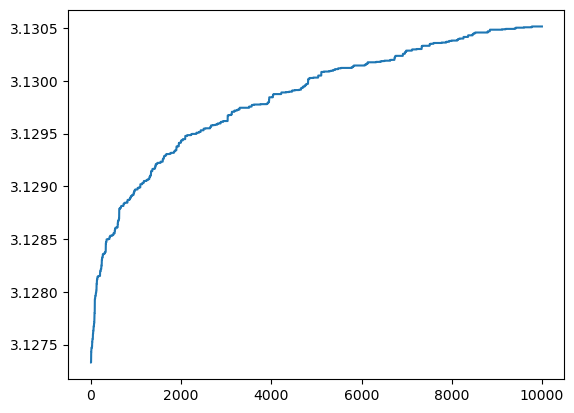

In [ ]:
sofa_w, sofa_h = 2, 2   # 求解域的尺寸

best_score, xs, ys, rotations, sofa, maximal_area_record = run_optimization(
    is_forbidden,
    # xs,
    # ys,
    # rotations,
    initial_xs=zoom(xs, zoom=2, order=1),
    initial_ys=zoom(ys, zoom=2, order=1),
    initial_rotations=zoom(rotations, zoom=2, order=1),
    sofa_w=sofa_w,
    sofa_h=sofa_h,
    mutation_sigma_pos = 0.002,  # 变异率 0.002
    mutation_sigma_rotation = 0,  # 变异率 0.004
    iterations = 10000,  # 200000
    trajectory_upsampling=41,  # 41 101
    resolution=1024,  # 1024 2000
    print_every=500,  # 1000
    save_image_every=50,
    save_image_path='../images/能让等边三角形旋转一周的房间_4/sofa_',
    save_image_start_id=1200,
    save_trajectory_path='../trajectory/能让等边三角形旋转一周的房间_4/sofa_'
)
print(f"Estimated maximal sofa area (by sampling): {best_score:.5f}")
# save mask image as PNG if pillow is available

img = (sofa * 255).astype(np.uint8)
im = Image.fromarray(img.T[::-1])
im.save('../sofa_survivors.png')
plt.plot(maximal_area_record)

In [164]:
sofa_w * sofa_h - maximal_area_record[-1]

0.8694839477539062

In [155]:
np.pi * (3 ** 0.5 / 3) ** 2  # 圆的面积

1.0471975511965976

0.84, 0.89, 0.86, 0.87